# Pretraining/evaluation overlap plots

This notebook reads the generated overlap CSV and visualizes the overlap percentage for each evaluation benchmark.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
ROOT = Path.cwd().resolve().parent
CSV_PATH = ROOT / 'analysis' / 'pretraining_eval_overlap.csv'
OUT_DIR = ROOT / 'analysis' / 'plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df = df.sort_values('n_eval', ascending=False).reset_index(drop=True)

def short_label(name: str) -> str:
    stem = Path(name).stem
    if stem.startswith('prepared/'):
        stem = stem[len('prepared/') :]
    if stem.endswith('.joblib'):
        stem = stem[: -len('.joblib')]
    return stem

df['dataset_label'] = df['dataset'].map(short_label)
df.head()

,dataset,n_eval,n_overlap,overlap_pct,dataset_label
0,prepared/ogbg-molmuv.joblib,93087,78559,84.3931,ogbg-molmuv
1,prepared/ogbg-molhiv.joblib,40859,18115,44.3354,ogbg-molhiv
2,prepared/hERG_Karim.joblib,13444,9946,73.9810,hERG_Karim
3,prepared/CYP2D6_Veith.joblib,13090,11489,87.7693,CYP2D6_Veith
4,prepared/CYP2C19_Veith.joblib,12627,11164,88.4137,CYP2C19_Veith


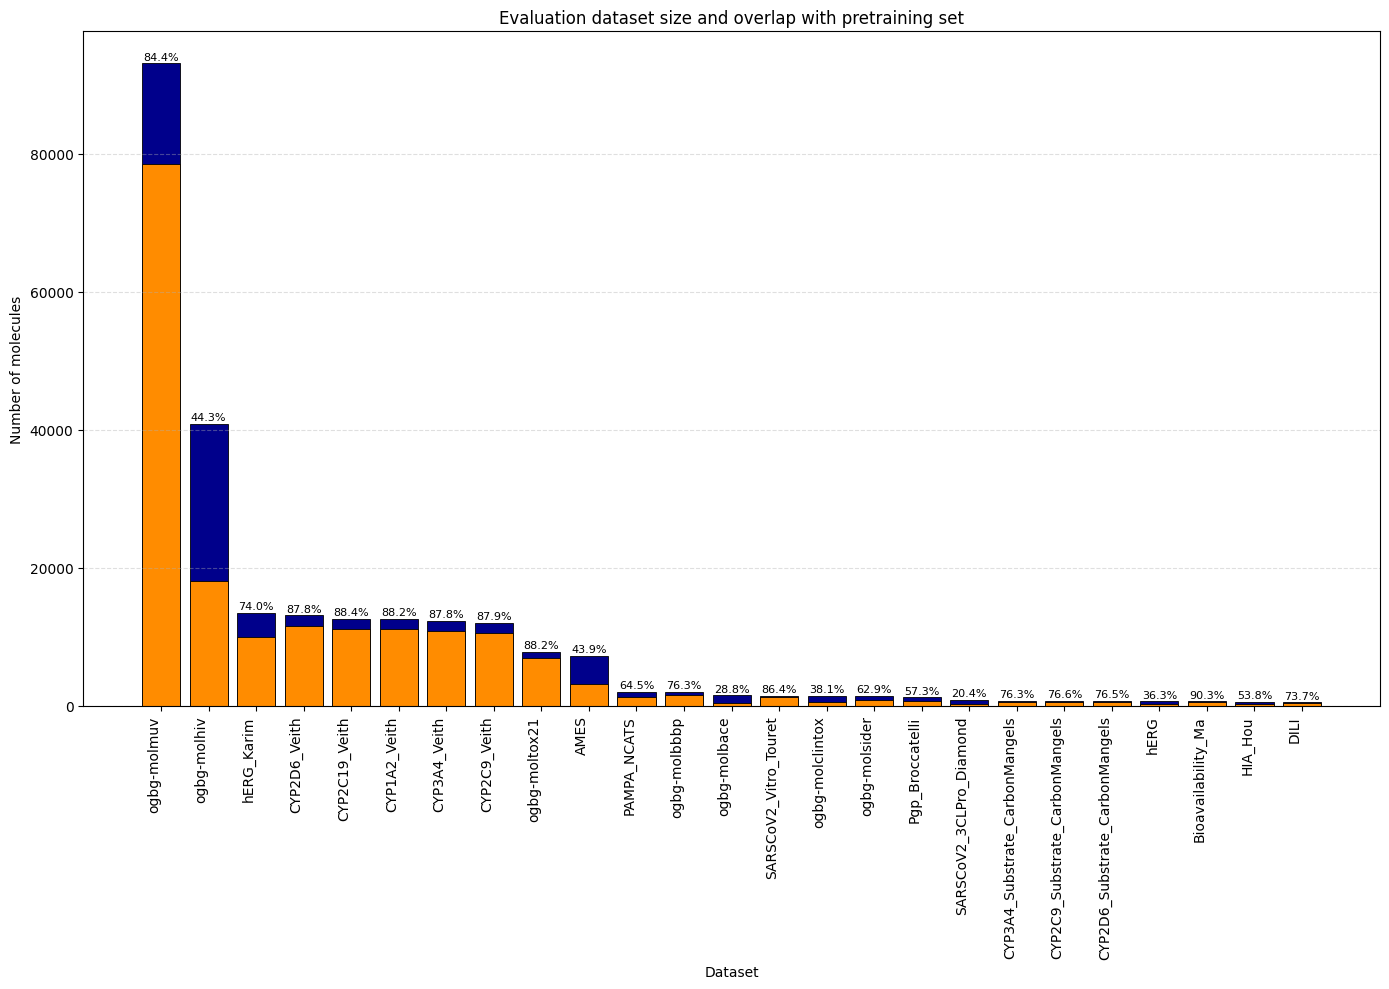

In [3]:
fig, ax = plt.subplots(figsize=(14, 10))
df['overlap_count'] = df['n_overlap'].astype(float)
non_overlap_count = df['n_eval'] - df['n_overlap']
bars = ax.bar(df['dataset_label'], df['n_eval'], color='darkblue', edgecolor='black', linewidth=0.6)
ax.bar(df['dataset_label'], df['n_overlap'], color='darkorange', edgecolor='black', linewidth=0.6)
ax.set_title('Evaluation dataset size and overlap with pretraining set')
ax.set_xlabel('Dataset')
ax.set_ylabel('Number of molecules')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xticks(range(len(df)))
ax.set_xticklabels(df['dataset_label'], rotation=90, ha='right')
for i, (bar, value, overlap) in enumerate(zip(bars, df['n_eval'], df['n_overlap'])):
    pct = df.loc[i, 'overlap_pct']
    ax.text(
        i,
        value + 250,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8,
        color='black',
    )
fig.tight_layout()
fig.savefig(OUT_DIR / 'pretraining_eval_overlap_stacked_bar.png', dpi=200)
plt.show()

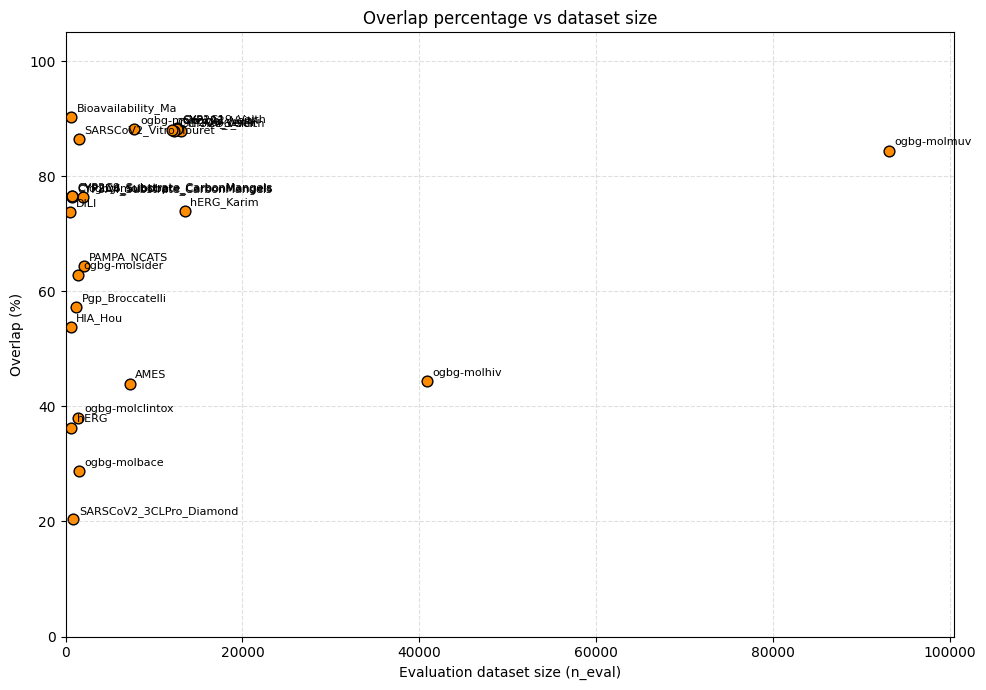

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df['n_eval'], df['overlap_pct'], s=60, c='darkorange', edgecolors='black')
for _, row in df.iterrows():
    ax.annotate(
        short_label(row['dataset']),
        (row['n_eval'], row['overlap_pct']),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
    )
ax.set_title('Overlap percentage vs dataset size')
ax.set_xlabel('Evaluation dataset size (n_eval)')
ax.set_ylabel('Overlap (%)')
ax.set_xlim(0, max(df['n_eval']) * 1.08)
ax.set_ylim(0, 105)
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / 'pretraining_eval_overlap_scatter.png', dpi=200)
plt.show()

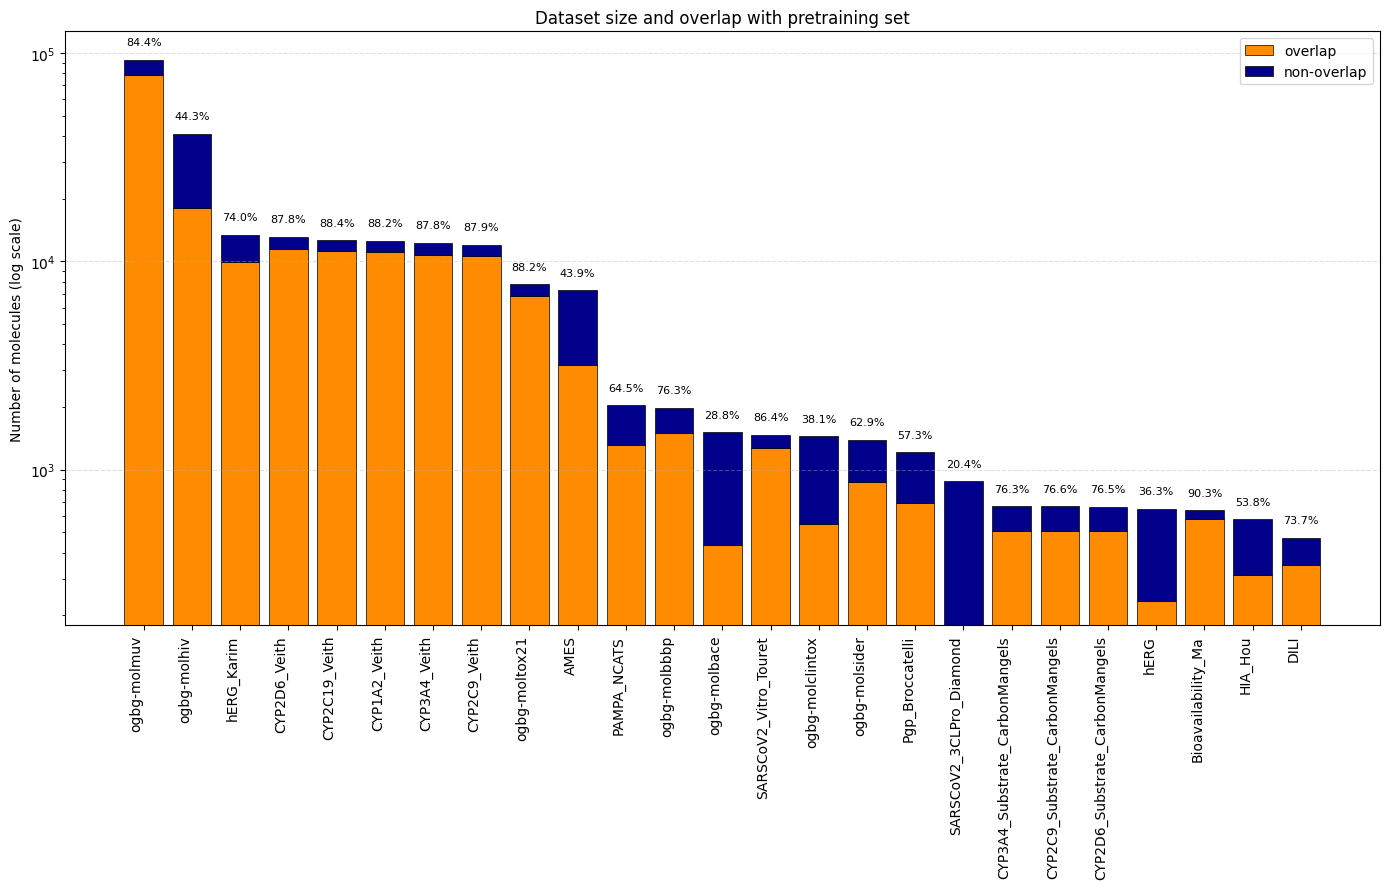

In [ ]:
# Stacked bar plot: orange overlap at bottom, blue non-overlap on top, y-axis in log scale
plot_df = df.copy()
plot_df['non_overlap'] = plot_df['n_eval'] - plot_df['n_overlap']
fig, ax = plt.subplots(figsize=(14, 9))
x = range(len(plot_df))
ax.bar(x, plot_df['n_overlap'], color='darkorange', edgecolor='black', linewidth=0.5, label='overlap')
ax.bar(x, plot_df['non_overlap'], bottom=plot_df['n_overlap'], color='darkblue', edgecolor='black', linewidth=0.5, label='non-overlap')
ax.set_xticks(list(x))
ax.set_xticklabels(plot_df['dataset_label'], rotation=90, ha='right')
ax.set_title('Dataset size and overlap with pretraining set')
ax.set_ylabel('Number of molecules (log scale)')
ax.set_yscale('log')
ax.grid(axis='y', linestyle='--', alpha=0.4)
for i, row in plot_df.iterrows():
    pct = row['overlap_pct']
    total = row['n_eval']
    ax.text(i, max(total * 1.15, 10), f'{pct:.1f}%', ha='center', va='bottom', fontsize=8, color='black')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'pretraining_eval_overlap_size_plus_overlap.png', dpi=200)
plt.show()